solo ratio distributions per species, LTR identity per species, Moran's I spatial autocorrelation (surpassed by DTW for dissertation), per-bin positional analyses. Lots of plotting.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.spatial import distance_matrix
from scipy.stats import norm
from matplotlib import font_manager
from libpysal.weights import DistanceBand
from esda.moran import Moran
from pathlib import Path

In [2]:
sample_order_path = "data/metadata.tsv"
sample_order = pd.read_csv(sample_order_path, sep='\t')['Species'].tolist()

In [ ]:

def load_bin_data(sample):
    path = Path(f"data/ratio_tables/{sample}_percent_counts.tsv")
    return pd.read_csv(path, sep="\t")

def load_fixed_window_size_data(sample):
    path = Path(f"data/ratio_tables/{sample}_counts.tsv")
    return pd.read_csv(path, sep="\t")

def compute_ratios(df, group):
    df[f"{group}_solo-intact_ratio"] = df[f"{group}_solo_count"] / df[f"{group}_intact_count"]
    df[f"{group}_solo-other_ratio"] = df[f"{group}_solo_count"] / (
        df[f"{group}_intact_count"] + df[f"{group}_disrupted_count"]
    )
    return df

def replace_inf_and_nan(df, columns):
    return df.replace([np.inf, -np.inf], np.nan).dropna(subset=columns)

def get_top_families(df, n=3):
    intact_cols = df.columns[df.columns.str.contains("intact_count")]
    means = df[intact_cols].mean()
    top_indices = means.nlargest(n + 1).index  # +1 to include "all"
    return [col.split("_")[0] for col in top_indices]

def plot_ratios(df, sample, families):
    chromosomes = df['chr'].dropna().unique()
    if len(chromosomes) < 6:
        selected = chromosomes
    else:
        selected = np.random.RandomState(42).choice(chromosomes, size=6, replace=False)
    sns.set_theme(style="whitegrid")

    for group in families:
        fig, axes = plt.subplots(2, 3, figsize=(18, 12), sharex=True, sharey=True)
        axes = axes.flatten()

        for i, chr in enumerate(selected):
            sub_df = df[df['chr'] == chr]
            ax = axes[i]
            for col, color in [(f"{group}_solo-intact_ratio", "blue"), (f"{group}_solo-other_ratio", "orange")]:
                sns.scatterplot(data=sub_df, x="bin_ID", y=col, color=color, label=col, ax=ax)
                sns.lineplot(data=sub_df, x="bin_ID", y=col, color=color, alpha=0.5, ax=ax)
            ax.set_title(chr)
            ax.set_xlabel("Bin ID")
            ax.set_ylabel("Ratio")
            ax.tick_params(axis='x', rotation=45)

        for j in range(len(selected), len(axes)):
            fig.delaxes(axes[j])

        plt.suptitle(f"{group} Ratios in {sample}", fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.savefig(f"data/figures/{sample}_{group}_solo-element_ratios_grid.png")
        plt.close()

def compute_morans_I(values, coords, threshold_fraction=0.2):
    values = np.array(values, dtype=float)
    coords = np.array(coords).reshape(-1, 1)
    mask = ~np.isnan(values)
    if mask.sum() < 3:
        return {'moran_I': np.nan, 'expected': np.nan, 'p_value': np.nan, 'weight_sum': 0, 'number_of_values': mask.sum()}
    
    values = values[mask]
    coords = coords[mask]
    
    w = DistanceBand(coords, threshold=coords.max() * threshold_fraction, binary=True, silence_warnings=True)
    moran = Moran(values, w)
    return {
        'moran_I': moran.I,
        'expected': moran.EI,
        'p_value': moran.p_sim,
        'weight_sum': w.s0,
        'number_of_values': len(values)
    }

def process_sample(sample, moran_threshold):
    df = load_bin_data(sample)
    df = compute_ratios(df, "all")
    df_solo_ratio = replace_inf_and_nan(df, ["all_solo-intact_ratio"])
    df_res_identity = replace_inf_and_nan(df, ["all_intact_LTR_identity"])

    df_fixed_size = load_fixed_window_size_data(sample)
    df_fixed_size = compute_ratios(df_fixed_size, "all")
    df_fixed_size_solo_ratio = replace_inf_and_nan(df_fixed_size, ["all_solo-intact_ratio"])
    df_fixed_size_res_identity = replace_inf_and_nan(df_fixed_size, ["all_intact_LTR_identity"])

    chromosomes = df['chr'].unique()
    results_solo_ratio = []

    for chr in chromosomes:
        chr_df = df_solo_ratio[df_solo_ratio['chr'] == chr]
        res = compute_morans_I(chr_df['all_solo-intact_ratio'], chr_df['bin_start'], moran_threshold)
        results_solo_ratio.append({
            'sample': sample,
            'chromosome': chr,
            'ratio': 'all_solo-intact_ratio',
            **res
        })

    results_identity = []
    for chr in chromosomes:
        chr_df = df_res_identity[df_res_identity['chr'] == chr]
        # check if there are enough valid values to compute Moran's I
        if chr_df['all_intact_LTR_identity'].isna().sum() >= len(chr_df) - 1:
            print(f"Warning: Not enough valid values to compute Moran's I for {sample} {chr}. Skipping.")
            results_identity.append({
                'sample': sample,
                'chromosome': chr,
                'identity': 'all_intact_LTR_identity',
                'moran_I': np.nan,
                'expected': np.nan,
                'p_value': np.nan,
                'weight_sum': 0,
                'number_of_values': chr_df['all_intact_LTR_identity'].notna().sum()
            })
            continue
        res = compute_morans_I(chr_df['all_intact_LTR_identity'], chr_df['bin_start'], moran_threshold)
        results_identity.append({
            'sample': sample,
            'chromosome': chr,
            'identity': 'all_intact_LTR_identity',
            **res
        })

    df['sample'] = sample
    df_fixed_size['sample'] = sample

    out_df = df[['sample', 'chr', 'bin_ID', 'bin_start', 'bin_end',
            'all_solo-intact_ratio', 'all_intact_LTR_identity',
            'all_intact_count', 'all_disrupted_count', 'all_solo_count']].copy()

    out_fixed_size_df = df_fixed_size[['sample', 'chr', 'bin_ID', 'bin_start', 'bin_end',
                                         'all_solo-intact_ratio', 'all_intact_LTR_identity', 
                                            'all_intact_count', 'all_disrupted_count', 'all_solo_count']].copy()
    

    df['sample'] = sample
    df_fixed_size['sample'] = sample

    out_df = df[['sample', 'chr', 'bin_ID', 'bin_start', 'bin_end',
                  'all_solo-intact_ratio', 'all_intact_LTR_identity',
                  'all_intact_count', 'all_disrupted_count', 'all_solo_count']].copy()

    out_fixed_size_df = df_fixed_size[['sample', 'chr', 'bin_ID', 'bin_start', 'bin_end',
                                         'all_solo-intact_ratio', 'all_intact_LTR_identity',
                                         'all_intact_count', 'all_disrupted_count', 'all_solo_count']].copy()
    
    return pd.DataFrame(results_solo_ratio), pd.DataFrame(results_identity), out_df, out_fixed_size_df

# Main processing

moran_threshold = 0.2

all_results = []
all_results_identity = []
all_bin_data = []
all_fixed_size_bin_data = []

for sample in sample_order:
    # Uncomment if you want the plots
    #df = load_bin_data(sample)
    #families = get_top_families(df)
    #for fam in families:
    #     df = compute_ratios(df, fam)
    #     df = replace_inf_and_nan(df, [f"{fam}_solo-intact_ratio", f"{fam}_solo-other_ratio"])
    #plot_ratios(df, sample, families)

    df_res, df_res_identity, bin_data, fixed_size_bin_data = process_sample(sample, moran_threshold)
    all_results.append(df_res)
    all_results_identity.append(df_res_identity)
    all_bin_data.append(bin_data)
    all_fixed_size_bin_data.append(fixed_size_bin_data)

final_results = pd.concat(all_results, ignore_index=True)
final_results_identity = pd.concat(all_results_identity, ignore_index=True)
final_bin_data = pd.concat(all_bin_data, ignore_index=True)
final_fixed_size_bin_data = pd.concat(all_fixed_size_bin_data, ignore_index=True)

final_results.to_csv(f"data/moran_results_{moran_threshold}.tsv", index=False, sep="\t")
final_results_identity.to_csv(f"data/moran_results_identity_{moran_threshold}.tsv", index=False, sep="\t")  
final_bin_data.to_csv("data/solo-intact_ratios.tsv", index=False, sep="\t")

final_fixed_size_bin_data.to_csv("data/solo-intact_ratios_fixed_size.tsv", index=False, sep="\t")


In [ ]:
from matplotlib import font_manager
import matplotlib

# Add fonts from the new directory to matplotlib
custom_fonts_path = "config/fonts"
custom_fonts = font_manager.findSystemFonts(fontpaths=custom_fonts_path, fontext='ttf')
for font in custom_fonts:
    try:
        font_manager.fontManager.addfont(font)
    except Exception as e:
        print(f"Skipping font {font} due to error: {e}")


matplotlib.rcParams['font.family'] = "sans-serif"
matplotlib.rcParams['font.sans-serif'] = "Arial"

In [5]:
# Load metadata
metadata_path = "data/metadata.tsv"
metadata = pd.read_csv(metadata_path, sep="\t")
colnames=['Order',
 'Species',
 'Chromosome_number_(n)',
 'Assembly_size_(Mb)',
 'Chromosome_size_(Mb)',
 'Chromosomes_in_analysis',
 'Assembly_size_in_analysis_(Mb)',
 'Accession',
 'Family',
 'Centromere_architecture',
 'Included_chromosomes',
 'Gaps_per_chr',
 'Gaps_per_Mb',
 'Busco_pct',
 'Short_label']
metadata.columns = colnames

# Merge bin_data_all with metadata
bin_data_merged = final_bin_data.merge(metadata[['Species', 'Centromere_architecture', 'Short_label']], left_on='sample', right_on='Species', how='right')

# Create a color palette for Centromere
palette = {"holocentric": "#000080", "monocentric": "gray"}

# Map short sample labels
short_sample_labels = bin_data_merged['Short_label'].unique().tolist()

bin_data_merged['sample'] = bin_data_merged['sample'].map(
    dict(zip(sample_order, short_sample_labels))
)

# Ensure the order of samples is correct
bin_data_merged['sample'] = pd.Categorical(bin_data_merged['sample'], categories=short_sample_labels, ordered=True)



In [6]:
# log transform the ratio for better visualization
bin_data_merged['log_all_solo-intact_ratio'] = np.log2(bin_data_merged['all_solo-intact_ratio'] + 1e-4)  # add small constant to avoid log(0)


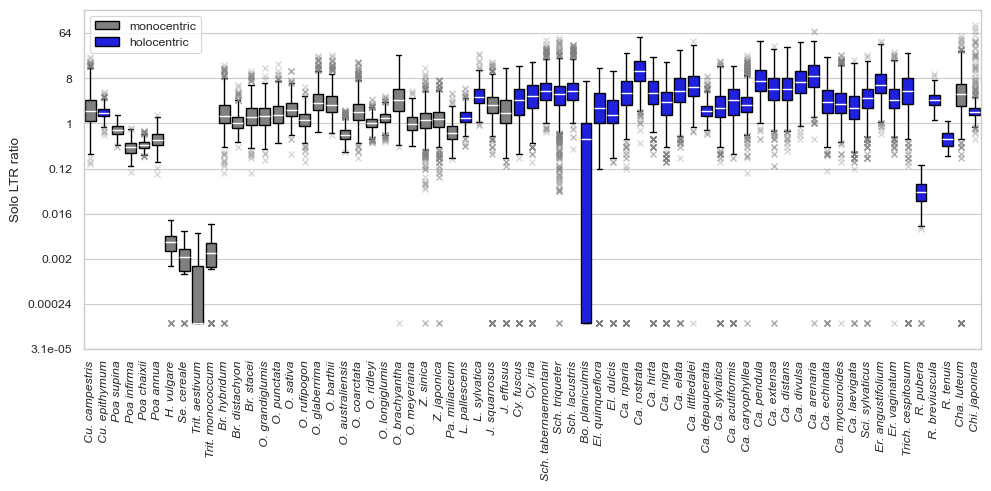

In [8]:
import matplotlib.ticker as ticker

# Plot solo-other ratios per sample, colored by centromere type
palette = {"holocentric": "#0000fff5", "monocentric": "gray"}
sns.set_theme(context="paper", style="whitegrid")
plt.figure(figsize=(10, 5))

# Set font to Arial
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'

# Create a boxplot for all_solo-other_ratio grouped by sample and colored by Centromere
ax = sns.boxplot(
    data=bin_data_merged, 
    x="sample", 
    y="log_all_solo-intact_ratio", 
    hue="Centromere_architecture", 
    palette=palette, 
    dodge=False, 
    linewidth=1, 
    linecolor="black",
    whiskerprops=dict(color='black'), 
    flierprops=dict(marker='x', markersize=5, markeredgecolor='gray', alpha=0.3),
    capprops=dict(color='black'), 
    medianprops=dict(color='white'), 
    boxprops=dict(edgecolor='black')
)

# Format y-axis to show back-transformed values
def log2_to_linear(y, pos):
    """Convert log2 values back to linear scale"""
    return f'{2**y:.2g}'  # Use .2g for clean formatting

ax.yaxis.set_major_formatter(ticker.FuncFormatter(log2_to_linear))

y_min, y_max = ax.get_ylim()
log_ticks = np.arange(np.floor(y_min), np.ceil(y_max) + 1, 3)
ax.set_yticks(log_ticks)

plt.xticks(rotation=90, fontstyle='italic')
plt.ylabel("Solo LTR ratio")  # Remove "(log2 scale)" from label
plt.xlabel("")
plt.legend(loc="upper left")
plt.tight_layout()

plt.savefig(f"data/figures/solo_intact_ratios_per_sample_by_centromere.svg", dpi=300)
plt.show()

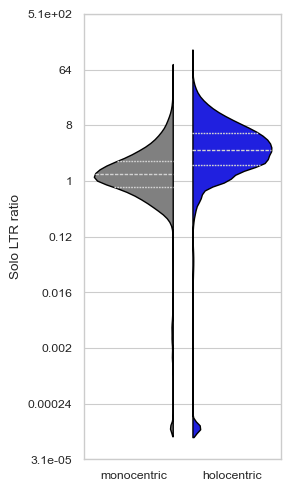

In [10]:
# Plot solo-other ratios per centromere type, colored by centromere type
sns.set_theme(context="paper", style="whitegrid")
plt.figure(figsize=(3, 5))
palette = {"holocentric": "#0000fff5", "monocentric": "gray"}


# Create a violin plot for all_solo-other_ratio grouped by Centromere
ax = sns.violinplot(
    data=bin_data_merged, 
    x="Centromere_architecture", 
    y="log_all_solo-intact_ratio", 
    hue="Centromere_architecture", 
    palette=palette, 
    dodge=False, 
    linewidth=1,
    linecolor="black",
    split=True, inner="quart",
)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(log2_to_linear))

y_min, y_max = ax.get_ylim()
log_ticks = np.arange(np.floor(y_min), np.ceil(y_max) + 1, 3)
ax.set_yticks(log_ticks)

for line in ax.lines:
    line.set_color('lightgray') 
plt.ylabel("Solo LTR ratio")
plt.xlabel("")
plt.tight_layout()

# Save the plot
plt.savefig(f"data/figures/solo_intact_ratios_violin_plot.svg", dpi=300)
plt.show()


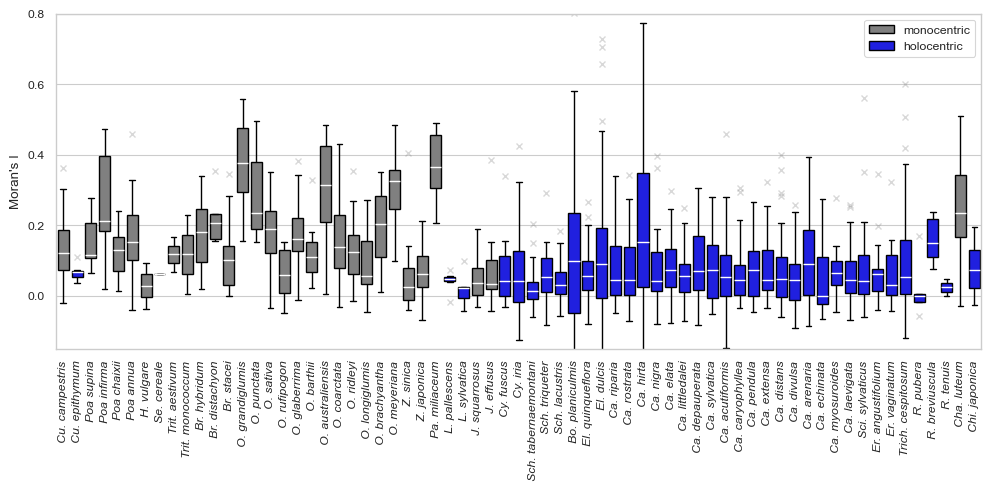

In [11]:
# Merge df_all with metadata to include Centromere information
df_all_merged = final_results.merge(metadata[['Species', 'Centromere_architecture']], left_on='sample', right_on='Species', how='right')

# Map short sample labels
df_all_merged['sample'] = df_all_merged['sample'].map(
    dict(zip(sample_order, short_sample_labels))
)
# Ensure the order of samples is correct
df_all_merged['sample'] = pd.Categorical(df_all_merged['sample'], categories=short_sample_labels, ordered=True)
# Set font to Arial
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'

# Plot Moran's I values per sample, colored by centromere type
plt.figure(figsize=(10, 5))
sns.set_theme()
sns.set_context("paper")
sns.set_style("whitegrid")

# Create a boxplot for Moran's I grouped by sample and colored by Centromere
sns.boxplot(data=df_all_merged, x="sample", y="moran_I", hue="Centromere_architecture", 
                    palette=palette, 
    dodge=False, 
    linewidth=1, 
    linecolor="black",
    whiskerprops=dict(color='black'), 
    flierprops=dict(marker='x', markersize=5, markeredgecolor='gray', alpha=0.3),
    capprops=dict(color='black'), 
    medianprops=dict(color='white'), 
    boxprops=dict(edgecolor='black')
)
plt.xticks(rotation=90, fontstyle='italic')  # Italicize x-ticks
plt.ylabel("Moran's I")
plt.ylim(-0.15,0.8)  # Limit y-axis to -0.2 to 0.6
plt.xlabel("")
plt.legend(loc='upper right')  # Adjust legend position
plt.tight_layout()

# Save the plot
plt.savefig(f"data/figures/morans_I_per_sample_by_centromere_{moran_threshold}.svg", dpi=300)
plt.show()

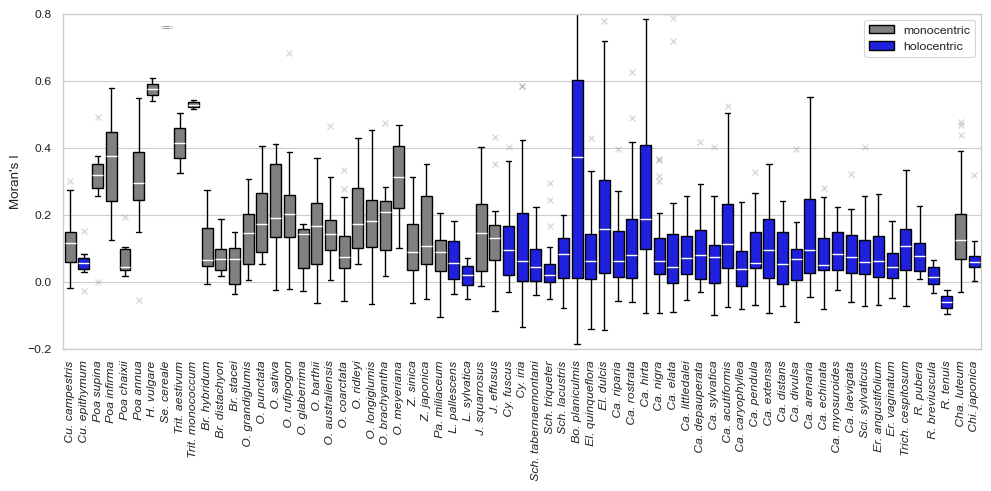

In [12]:
# Merge df_all with metadata to include Centromere information
df_identity_merged = final_results_identity.merge(metadata[['Species', 'Centromere_architecture']], left_on='sample', right_on='Species', how='right')

# Map short sample labels
df_identity_merged['sample'] = df_identity_merged['sample'].map(
    dict(zip(sample_order, short_sample_labels))
)
# Ensure the order of samples is correct
df_identity_merged['sample'] = pd.Categorical(df_identity_merged['sample'], categories=short_sample_labels, ordered=True)
# Set font to Arial
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'

# Plot Moran's I values per sample, colored by centromere type
plt.figure(figsize=(10, 5))
sns.set_theme()
sns.set_context("paper")
sns.set_style("whitegrid")

# Create a boxplot for Moran's I grouped by sample and colored by Centromere
sns.boxplot(data=df_identity_merged, x="sample", y="moran_I", hue="Centromere_architecture", 
                    palette=palette, 
    dodge=False, 
    linewidth=1, 
    linecolor="black",
    whiskerprops=dict(color='black'), 
    flierprops=dict(marker='x', markersize=5, markeredgecolor='gray', alpha=0.3),
    capprops=dict(color='black'), 
    medianprops=dict(color='white'), 
    boxprops=dict(edgecolor='black')
)
plt.xticks(rotation=90, fontstyle='italic')  # Italicize x-ticks
plt.ylabel("Moran's I")
plt.ylim(-0.2,0.8)  # Limit y-axis to -0.2 to 0.6
plt.xlabel("")
plt.legend(loc='upper right')  # Adjust legend position
plt.tight_layout()

# Save the plot
plt.savefig(f"data/figures/morans_I_per_sample_identity_{moran_threshold}.svg")


Analyse chromosome-wide position of elements (this could give insights into their preffered niche (pericentromere, subtelomere...))

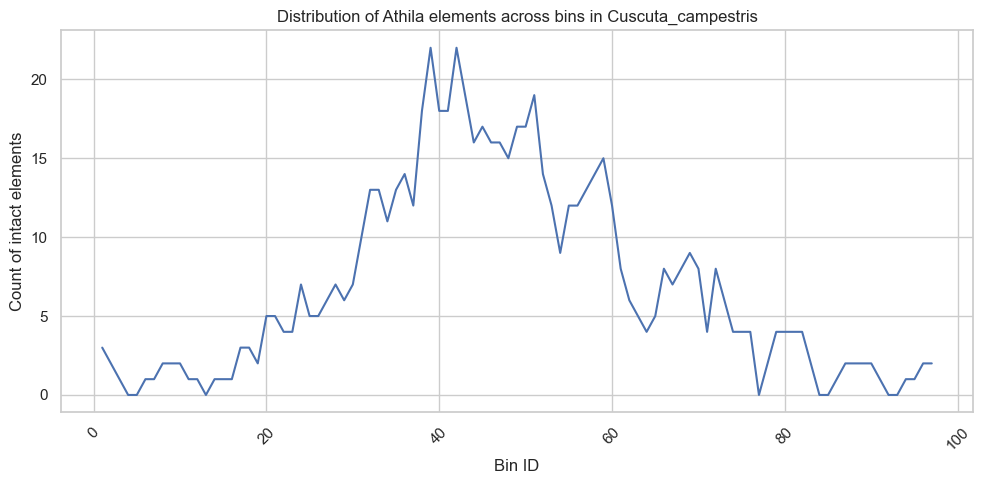

In [13]:
df=load_bin_data(sample_order[0])
# filter to only column bin_ID and *_intact_count
df_filtered = df[['bin_ID'] + [col for col in df.columns if col.endswith('_intact_count')]]
# sum counts in each bin across chromosomes
df_summed = df_filtered.groupby('bin_ID').sum().reset_index()

# plot the count distribution in bins for each family
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_summed, x='bin_ID', y='Athila_intact_count')
plt.xlabel("Bin ID")
plt.ylabel("Count of intact elements")
plt.title(f"Distribution of Athila elements across bins in {sample_order[0]}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"data/figures/element_distribution/intact_elements_distribution_{sample_order[0]}.svg", dpi=300)
plt.show()